# Layer 0: Data Source, Ingestion & Exploratory Data Analysis
## NASA Aviation Safety Reporting System (ASRS) — 2018 to March 2026

**What this notebook covers:**
1. What ASRS is and why it's the right data source
2. Raw file inventory — 17 batch exports, the 6-month window convention
3. The XLS/TSV two-header-row ingestion trick
4. How the 17 files are merged into a single analysis corpus
5. Mandatory EDA — completeness, distributions, temporal patterns, text quality
6. Data quality decisions that carry forward into Layers 1–4

In [1]:
import sys
import os
sys.path.insert(0, '..')  # project root so `from src.X import ...` works

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'x',
    'grid.alpha': 0.3,
})

---
## 1. The Data Source: NASA ASRS

The **Aviation Safety Reporting System** is a voluntary, confidential, non-punitive incident reporting programme operated by NASA on behalf of the FAA since 1976.  
Pilots, controllers, dispatchers, and cabin crew submit reports describing safety events they experienced or observed.

**Why ASRS for early warning?**
- Voluntary and confidential → reporters describe what actually happened, not what the regulations require them to say
- Free-text narrative → captures emerging threats before taxonomy categories exist
- 8-week reporting window → leading indicator, not lagging accident statistic
- Machine-readable batch exports → amenable to NLP and statistical process control

**What ASRS is not:**
- Not a complete census of aviation incidents (voluntary, so self-selected)
- Not severity-ranked (a near-miss and a paperwork error both generate reports)
- Not real-time (batches released quarterly)

**Download:** https://asrs.arc.nasa.gov/search/database.html  
Query: All anomaly types · All aircraft · Date range selected per batch · Max 10,000 records per export

In [2]:
# File inventory — 17 batch exports covering Jan 2018 to Mar 2026
raw_dir = '../data/raw'
files = sorted(f for f in os.listdir(raw_dir) if f.endswith('.xls') or f.endswith('.xlsx'))

print(f"Total batch files : {len(files)}")
print(f"{'File':<45}  {'Size':>8}")
print('-' * 56)
for f in files:
    size_kb = os.path.getsize(os.path.join(raw_dir, f)) / 1024
    print(f"  {f:<43}  {size_kb:>6.0f} KB")

Total batch files : 16
File                                               Size
--------------------------------------------------------
  ASRS_DBOnline_Jan18-June18.xls                 6686 KB
  ASRS_DBOnline_Jan19-June19.xls                 6853 KB
  ASRS_DBOnline_Jan20-Dec20.xls                 12405 KB
  ASRS_DBOnline_Jan21_June21.xls                 6233 KB
  ASRS_DBOnline_Jan22-June22.xls                 7692 KB
  ASRS_DBOnline_Jan23-June23.xls                 6116 KB
  ASRS_DBOnline_Jan24-Jun24.xls                  7222 KB
  ASRS_DBOnline_Jan25-June25.xls                 7834 KB
  ASRS_DBOnline_Jan26-Mar26.xls                  1694 KB
  ASRS_DBOnline_July18-Dec18.xls                 8118 KB
  ASRS_DBOnline_July19-Dec19.xls                 9746 KB
  ASRS_DBOnline_July21-Dec21.xls                 5961 KB
  ASRS_DBOnline_July22-Dec22.xls                 6422 KB
  ASRS_DBOnline_July23-Dec23.xls                 5959 KB
  ASRS_DBOnline_July24-Dec24.xls                 6546 KB
  ASRS_DB

### File naming convention

| Pattern | Coverage | Note |
| --- | --- | --- |
| `Jan18-June18`, `July18-Dec18` | Standard 6-month windows | Two files per year |
| `Jan20-Dec20` | Full year in one file | COVID year — ASRS published as single batch |
| `Jan26-Mar26` | Partial 2026 | Most recent batch at time of download |

### The file format gotcha

The files have `.xls` extension but are **tab-separated text** files, not binary Excel.  
Additionally, the ASRS export uses **two header rows**: the first row is the column group (e.g. `Aircraft 1`), the second row is the field name (e.g. `Flight Phase`).  
Reading these incorrectly collapses the hierarchy or produces garbled column names.

In [3]:
# Demonstrate the two-header-row structure on one raw file
sample_file = os.path.join(raw_dir, files[0])

# What pandas reads if you treat it naively (header=0)
df_naive = pd.read_csv(sample_file, sep='\t', encoding='utf-8', nrows=1,
                       on_bad_lines='skip')
print("=== NAIVE (header=0) — first 4 columns ===")
for c in df_naive.columns[:4]:
    print(f"  '{c}'")

print()

# The correct approach: read both header rows as a MultiIndex, then flatten
df_raw = pd.read_csv(sample_file, sep='\t', encoding='utf-8',
                     header=[0, 1], nrows=1, on_bad_lines='skip')
print("=== CORRECT (header=[0,1]) — MultiIndex before flattening ===")
for a, b in df_raw.columns[:4]:
    print(f"  ('{a.strip()}', '{b.strip()}')")

print()

# Flatten: 'Group | Field' except where group is unnamed
df_raw.columns = [
    f"{str(a).strip()} | {str(b).strip()}"
    if str(a).strip() and not str(a).startswith('Unnamed')
    else str(b).strip()
    for a, b in df_raw.columns
]
print("=== AFTER FLATTENING — first 8 columns ===")
for c in df_raw.columns[:8]:
    print(f"  '{c}'")

=== NAIVE (header=0) — first 4 columns ===
  ' '
  'Time'
  'Time.1'
  'Place'

=== CORRECT (header=[0,1]) — MultiIndex before flattening ===
  ('', 'ACN')
  ('Time', 'Date')
  ('Time', 'Local Time Of Day')
  ('Place', 'Locale Reference')

=== AFTER FLATTENING — first 8 columns ===
  'ACN'
  'Time | Date'
  'Time | Local Time Of Day'
  'Place | Locale Reference'
  'Place | State Reference'
  'Place | Relative Position.Angle.Radial'
  'Place | Relative Position.Distance.Nautical Miles'
  'Place | Altitude.AGL.Single Value'


---
## 2. Loading and Merging All Files

In [4]:
# load_and_merge_asrs() in src/data_loader.py does four things:
#   1. Reads each .xls as TSV with header=[0,1] and flattens column names
#   2. Parses `Time | Date` (YYYYMM integer) into a proper datetime column
#   3. Concatenates Report 1 + Report 2 narratives into `full_narrative`
#   4. Saves the merged frame to outputs/data/asrs_merged.parquet
#
# We load from the pre-computed parquet (fast; avoids re-reading 17 TSV files)
from src.data_loader import load_and_merge_asrs  # import verifies module works

asrs = pd.read_parquet('../outputs/data/asrs_merged.parquet')
asrs['date'] = pd.to_datetime(asrs['date'], errors='coerce')

print(f"Shape          : {asrs.shape[0]:,} rows × {asrs.shape[1]} columns")
print(f"Date range     : {asrs['date'].min().strftime('%b %Y')} → {asrs['date'].max().strftime('%b %Y')}")
print(f"ACN range      : {asrs['ACN'].min():,} → {asrs['ACN'].max():,}")
print(f"Parquet size   : {os.path.getsize('../outputs/data/asrs_merged.parquet') / 1024**2:.1f} MB")
print()
print("Layer 0 added columns:")
for c in ['date', 'full_narrative', 'narrative_word_count']:
    print(f"  {c}")

Shape          : 43,829 rows × 129 columns
Date range     : Jun 2002 → Mar 2026
ACN range      : 1,507,557 → 2,340,813
Parquet size   : 84.2 MB

Layer 0 added columns:
  date
  full_narrative
  narrative_word_count


---
## 3. Column Structure — 129 Fields Across 6 Groups

| Group | Key fields | Completeness |
| --- | --- | --- |
| **Time / Place** | `date`, `Local Time Of Day`, `Locale Reference` | date: 100%, others: 86–91% |
| **Aircraft 1** | `Flight Phase`, `Aircraft Operator`, `Make Model Name` | 94–100% |
| **Aircraft 2** | Second aircraft in a conflict/NMAC | 9–20% (multi-aircraft events only) |
| **Events** | `Anomaly` (semicolon-separated taxonomy), `Detector`, `Result` | 96–100% |
| **Assessments** | `Primary Problem`, `Contributing Factors / Situations` | ~100% |
| **Person 1 / 2** | `Function`, `Human Factors`, `Reporter Organization` | Person 1: 79–99%; Person 2: 5–21% |
| **Report** | `Narrative` (free text), `Synopsis` | Narrative: 100%, Synopsis: 100% |

The early-warning system primarily uses **`Events | Anomaly`** (structured taxonomy for SPC), **`full_narrative`** (free text for BERTopic, risk scoring, and RAG), and the five IF feature columns.

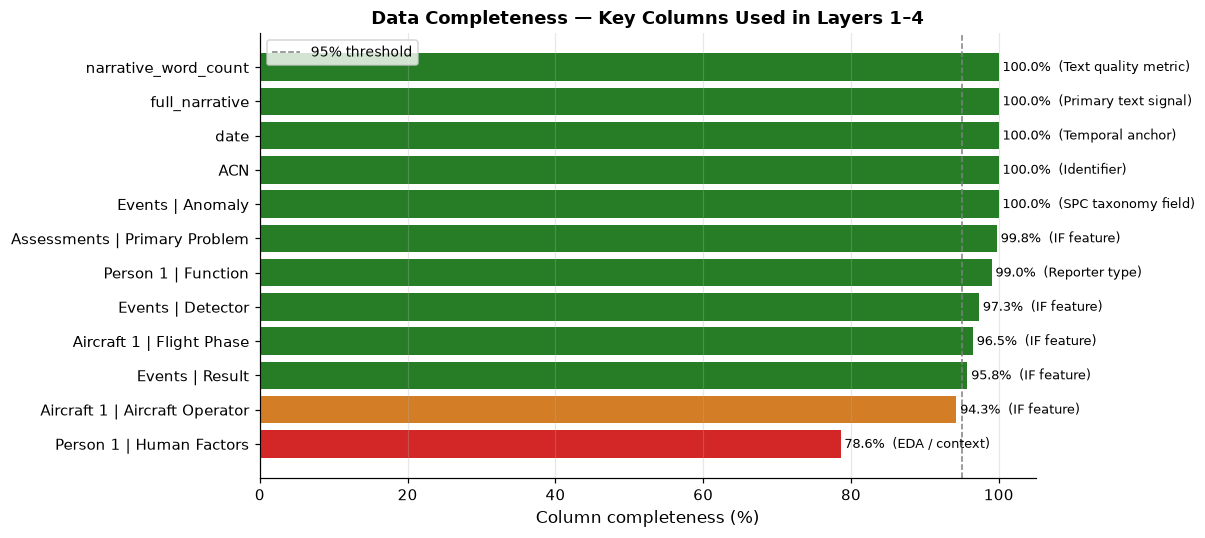

In [5]:
# Completeness for the 12 columns used in Layers 1–4
key_cols = [
    ('ACN', 'Identifier'),
    ('date', 'Temporal anchor'),
    ('full_narrative', 'Primary text signal'),
    ('narrative_word_count', 'Text quality metric'),
    ('Events | Anomaly', 'SPC taxonomy field'),
    ('Aircraft 1 | Flight Phase', 'IF feature'),
    ('Aircraft 1 | Aircraft Operator', 'IF feature'),
    ('Events | Detector', 'IF feature'),
    ('Events | Result', 'IF feature'),
    ('Assessments | Primary Problem', 'IF feature'),
    ('Person 1 | Human Factors', 'EDA / context'),
    ('Person 1 | Function', 'Reporter type'),
]

completeness = []
for col, role in key_cols:
    if col in asrs.columns:
        pct = asrs[col].notna().mean() * 100
        completeness.append((col, role, pct))

df_comp = pd.DataFrame(completeness, columns=['Column', 'Role', 'Complete %'])
df_comp = df_comp.sort_values('Complete %')

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#cc0000' if v < 80 else '#cc6600' if v < 95 else '#006600'
          for v in df_comp['Complete %']]
bars = ax.barh(df_comp['Column'], df_comp['Complete %'], color=colors, alpha=0.85)
ax.set_xlim(0, 105)
ax.axvline(95, color='grey', linestyle='--', linewidth=1, label='95% threshold')
for bar, (_, row) in zip(bars, df_comp.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{row['Complete %']:.1f}%  ({row['Role']})",
            va='center', fontsize=8.5)
ax.set_xlabel('Column completeness (%)', fontsize=11)
ax.set_title('Data Completeness — Key Columns Used in Layers 1–4',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()

---
## 4. Temporal Coverage

In [6]:
# 4 stray pre-2018 records — artefacts in the ASRS batch exports
stray = asrs[asrs['date'].dt.year < 2018]
print(f"Pre-2018 stray records: {len(stray)} ({len(stray)/len(asrs)*100:.3f}% of corpus)")
stray[['ACN', 'date', 'Events | Anomaly']].assign(
    anomaly_preview=stray['Events | Anomaly'].str[:80]
)[['ACN', 'date', 'anomaly_preview']]

Pre-2018 stray records: 4 (0.009% of corpus)


,ACN,date,anomaly_preview
0,1909753,2002-06-01,Aircraft Equipment Problem Critical; Deviation...
1,1823845,2012-07-01,Conflict Airborne Conflict; Deviation - Altitu...
2,2205580,2015-01-01,Conflict NMAC; Deviation / Discrepancy - Proce...
3,2224585,2015-03-01,"ATC Issue All Types; Conflict Ground Conflict,..."


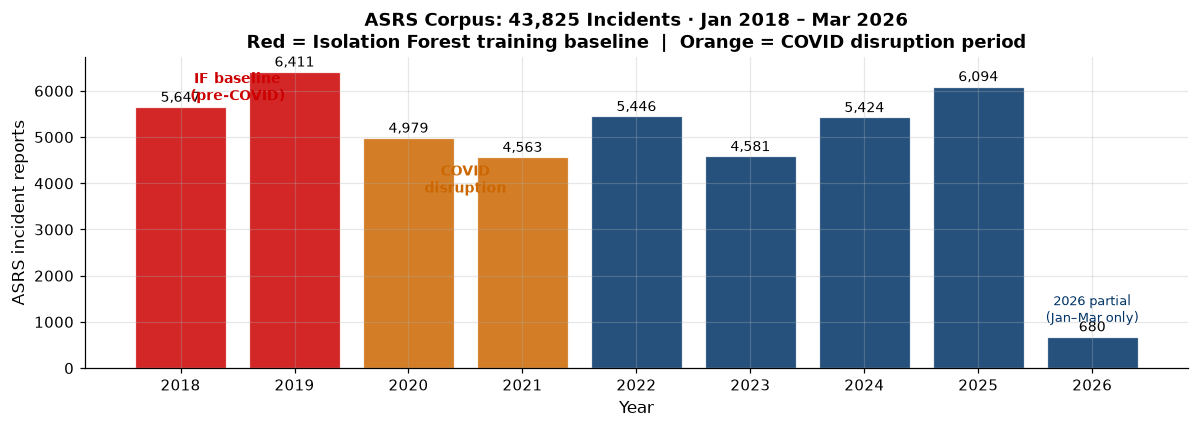

In [7]:
# Year-level volume with COVID annotation
asrs_valid = asrs[asrs['date'].dt.year >= 2018].copy()
year_counts = asrs_valid['date'].dt.year.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
bar_colors = [
    '#cc0000' if y in [2018, 2019] else   # IF baseline (highlighted)
    '#cc6600' if y in [2020, 2021] else   # COVID disruption
    '#003366'
    for y in year_counts.index
]
bars = ax.bar(year_counts.index, year_counts.values,
              color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.8)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 45,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

# Annotations
ax.annotate('IF baseline\n(pre-COVID)', xy=(2018.5, 5800), fontsize=9,
            color='#cc0000', ha='center', fontweight='bold')
ax.annotate('COVID\ndisruption', xy=(2020.5, 3800), fontsize=9,
            color='#cc6600', ha='center', fontweight='bold')
ax.annotate('2026 partial\n(Jan–Mar only)', xy=(2026, 1000), fontsize=8.5,
            color='#003366', ha='center')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('ASRS incident reports', fontsize=11)
ax.set_title(
    f'ASRS Corpus: {len(asrs_valid):,} Incidents · Jan 2018 – Mar 2026\n'
    'Red = Isolation Forest training baseline  |  Orange = COVID disruption period',
    fontsize=12, fontweight='bold'
)
ax.set_xticks(year_counts.index)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

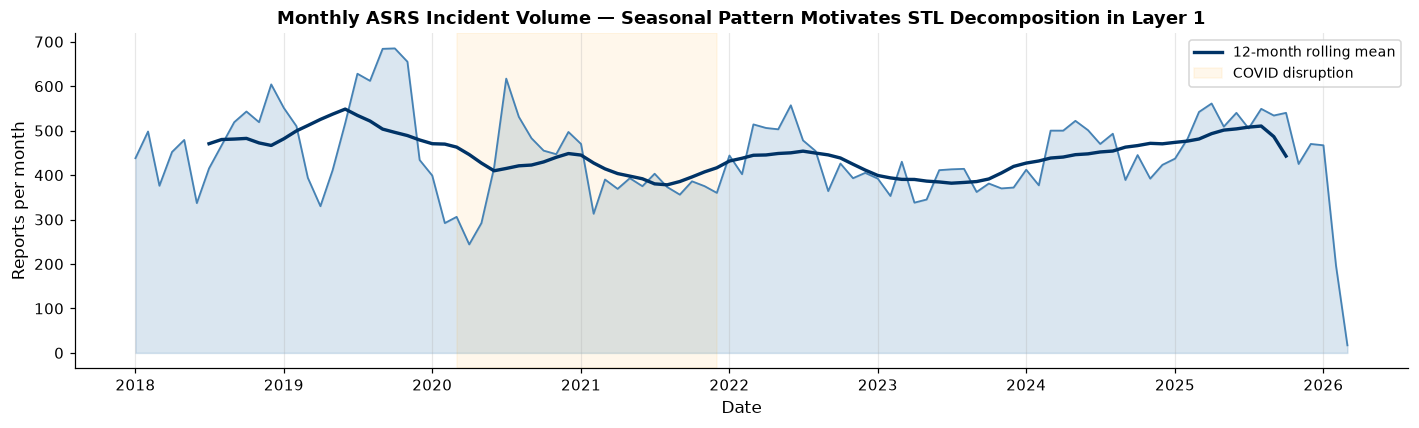

In [8]:
# Monthly volume — shows seasonality that motivates STL decomposition in Layer 1
monthly = (
    asrs_valid
    .groupby(asrs_valid['date'].dt.to_period('M'))['ACN'].count()
    .to_timestamp()
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(monthly.index, monthly.values, alpha=0.2, color='steelblue')
ax.plot(monthly.index, monthly.values, color='steelblue', linewidth=1.2)

# 12-month rolling mean
rolling = monthly.rolling(12, center=True).mean()
ax.plot(rolling.index, rolling.values, color='#003366', linewidth=2.2,
        label='12-month rolling mean')

# COVID annotation
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'),
           alpha=0.08, color='orange', label='COVID disruption')

ax.set_ylabel('Reports per month', fontsize=11)
ax.set_title(
    'Monthly ASRS Incident Volume — Seasonal Pattern Motivates STL Decomposition in Layer 1',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9)
ax.set_xlabel('Date', fontsize=11)
plt.tight_layout()

The monthly chart reveals a clear **summer peak** and **December–January trough** driven by seasonal flight operations.  
Layer 1's SPC pipeline removes this seasonality via STL decomposition before running CUSUM — preventing seasonal peaks from being misclassified as anomalous frequency shifts.

---
## 5. Incident Taxonomy — What ASRS Tracks

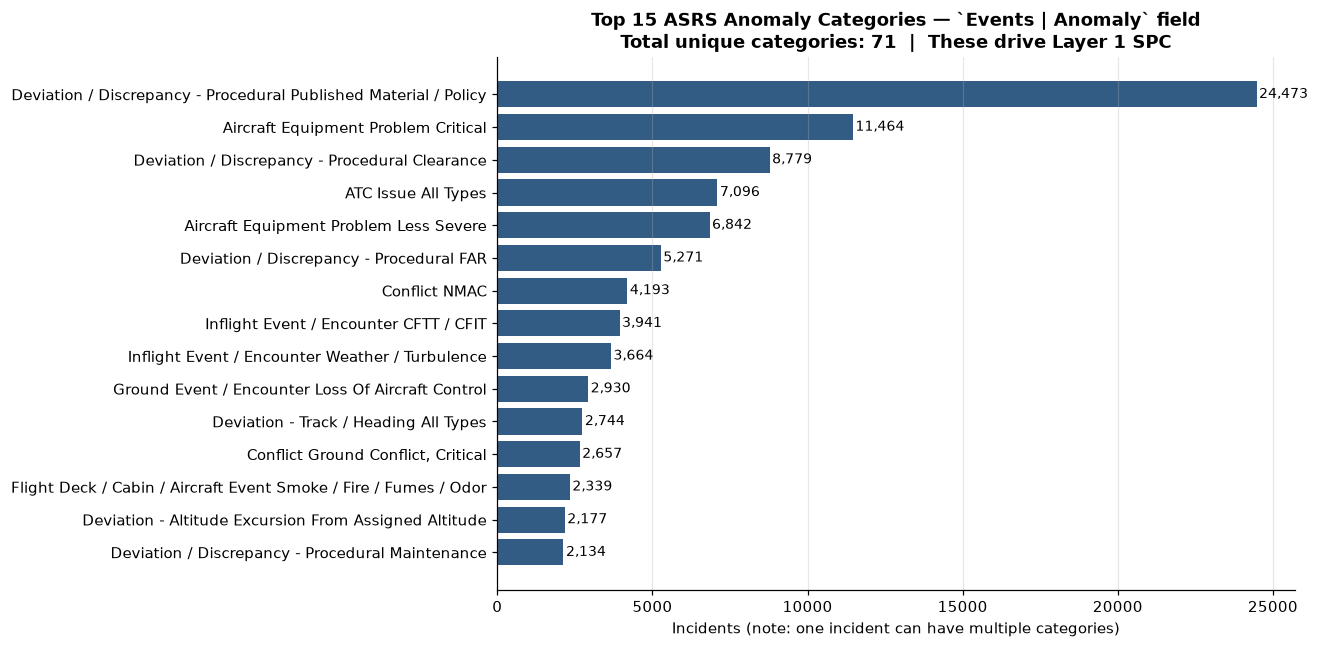

In [9]:
# Events | Anomaly is semicolon-separated — one incident can have multiple categories
# This is the field that drives Layer 1 SPC
all_types = {}
for val in asrs_valid['Events | Anomaly'].fillna(''):
    for t in val.split(';'):
        t = t.strip()
        if t and len(t) > 2:
            all_types[t] = all_types.get(t, 0) + 1

top15 = pd.Series(all_types).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = range(len(top15))
bars = ax.barh(list(reversed(top15.index)), list(reversed(top15.values)),
               color='#003366', alpha=0.8)
for bar in bars:
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)
ax.set_xlabel('Incidents (note: one incident can have multiple categories)', fontsize=10)
ax.set_title(
    'Top 15 ASRS Anomaly Categories — `Events | Anomaly` field\n'
    f'Total unique categories: {len(all_types)}  |  These drive Layer 1 SPC',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()

In [10]:
# Multi-category rate — how often does one incident span multiple taxonomy categories?
category_counts = asrs_valid['Events | Anomaly'].fillna('').apply(
    lambda x: len([t for t in x.split(';') if t.strip() and len(t.strip()) > 2])
)
print(f"Incidents with 1 category  : {(category_counts == 1).sum():>6,} ({(category_counts==1).mean()*100:.1f}%)")
print(f"Incidents with 2 categories: {(category_counts == 2).sum():>6,} ({(category_counts==2).mean()*100:.1f}%)")
print(f"Incidents with 3+ categories: {(category_counts >= 3).sum():>6,} ({(category_counts>=3).mean()*100:.1f}%)")
print(f"Mean categories per incident: {category_counts.mean():.2f}")
print(f"Max categories on one incident: {category_counts.max()}")

Incidents with 1 category  :  8,267 (18.9%)
Incidents with 2 categories: 11,857 (27.1%)
Incidents with 3+ categories: 23,694 (54.1%)
Mean categories per incident: 2.79
Max categories on one incident: 11


---
## 6. Incident Context — Flight Phase, Primary Problem, Operator

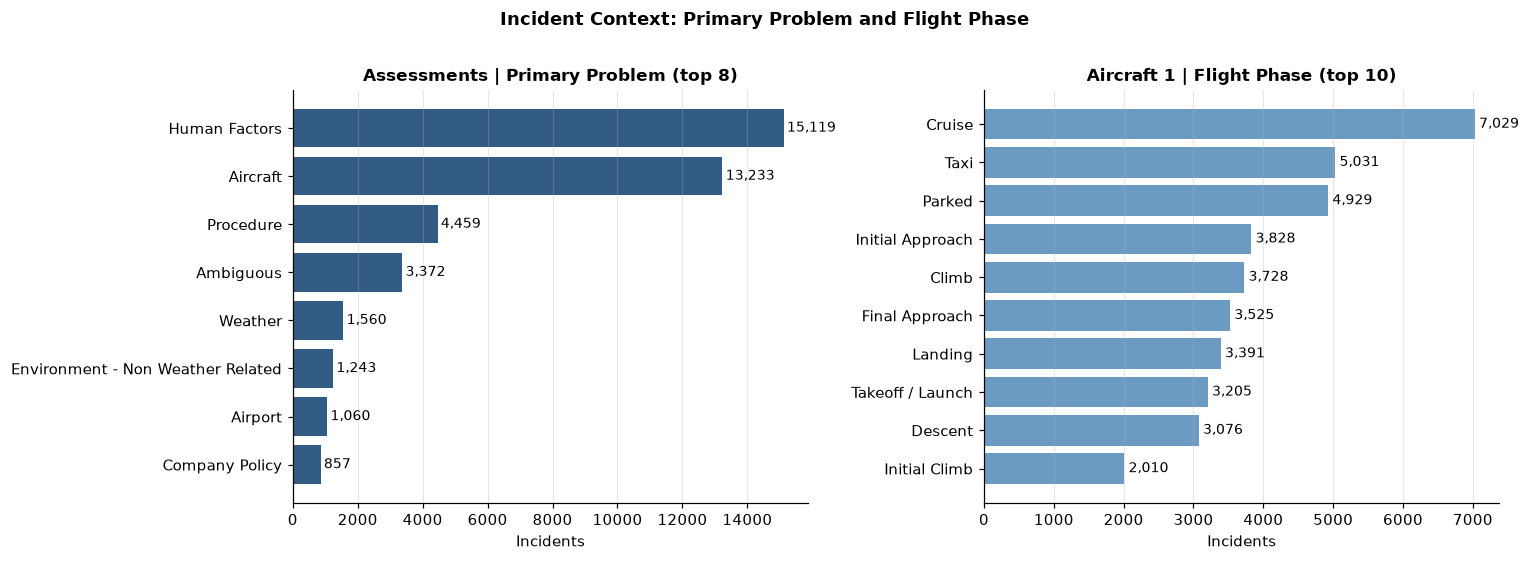

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Primary Problem
pp = asrs_valid['Assessments | Primary Problem'].value_counts().head(8)
axes[0].barh(pp.index[::-1], pp.values[::-1], color='#003366', alpha=0.8)
for i, v in enumerate(pp.values[::-1]):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)
axes[0].set_xlabel('Incidents', fontsize=10)
axes[0].set_title('Assessments | Primary Problem (top 8)', fontsize=11, fontweight='bold')

# Right: Flight Phase
fp = asrs_valid['Aircraft 1 | Flight Phase'].value_counts().head(10)
axes[1].barh(fp.index[::-1], fp.values[::-1], color='steelblue', alpha=0.8)
for i, v in enumerate(fp.values[::-1]):
    axes[1].text(v + 60, i, f'{v:,}', va='center', fontsize=9)
axes[1].set_xlabel('Incidents', fontsize=10)
axes[1].set_title('Aircraft 1 | Flight Phase (top 10)', fontsize=11, fontweight='bold')

plt.suptitle('Incident Context: Primary Problem and Flight Phase',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()

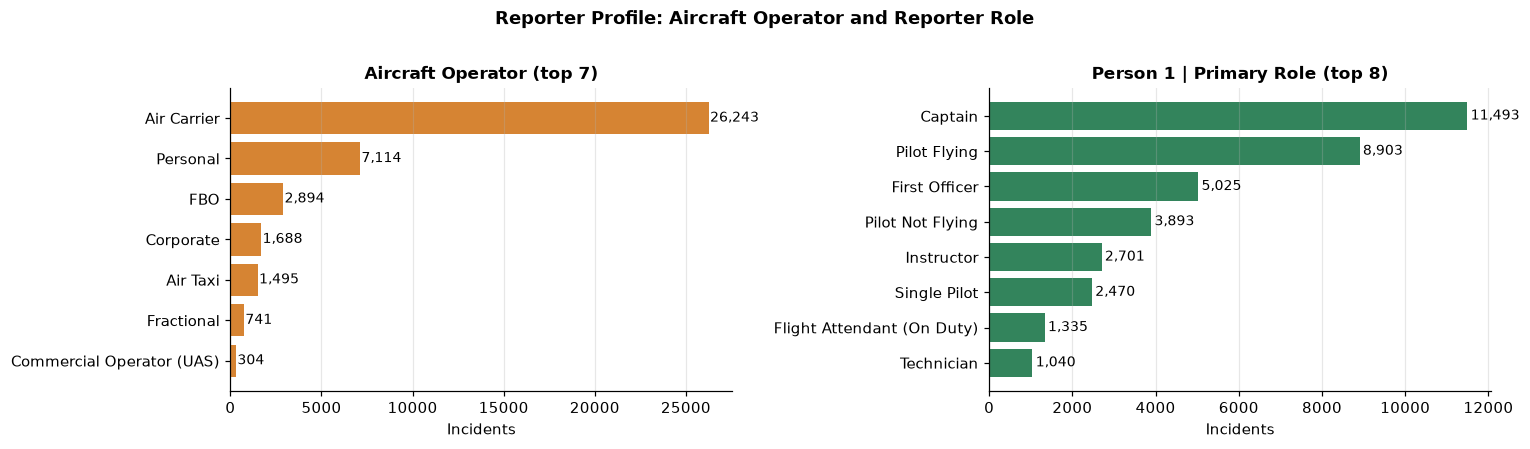

In [12]:
# Aircraft operator and reporter function
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Aircraft Operator
op = asrs_valid['Aircraft 1 | Aircraft Operator'].value_counts().head(7)
axes[0].barh(op.index[::-1], op.values[::-1], color='#cc6600', alpha=0.8)
for i, v in enumerate(op.values[::-1]):
    axes[0].text(v + 80, i, f'{v:,}', va='center', fontsize=9)
axes[0].set_xlabel('Incidents', fontsize=10)
axes[0].set_title('Aircraft Operator (top 7)', fontsize=11, fontweight='bold')

# Right: Reporter function (collapse variants)
func = asrs_valid['Person 1 | Function'].fillna('Unknown')
func_clean = func.str.split(';').str[0].str.strip()  # take primary role only
func_counts = func_clean.value_counts().head(8)
axes[1].barh(func_counts.index[::-1], func_counts.values[::-1], color='#006633', alpha=0.8)
for i, v in enumerate(func_counts.values[::-1]):
    axes[1].text(v + 80, i, f'{v:,}', va='center', fontsize=9)
axes[1].set_xlabel('Incidents', fontsize=10)
axes[1].set_title('Person 1 | Primary Role (top 8)', fontsize=11, fontweight='bold')

plt.suptitle('Reporter Profile: Aircraft Operator and Reporter Role',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()

**Air Carrier dominance (60%)** reflects the commercial aviation focus of ASRS.  
The personal/general aviation segment (16%) is underrepresented relative to its share of total flight hours — reporting culture is stronger in regulated commercial operations.

---
## 7. Human Factors — What Reporters Cite as Causal

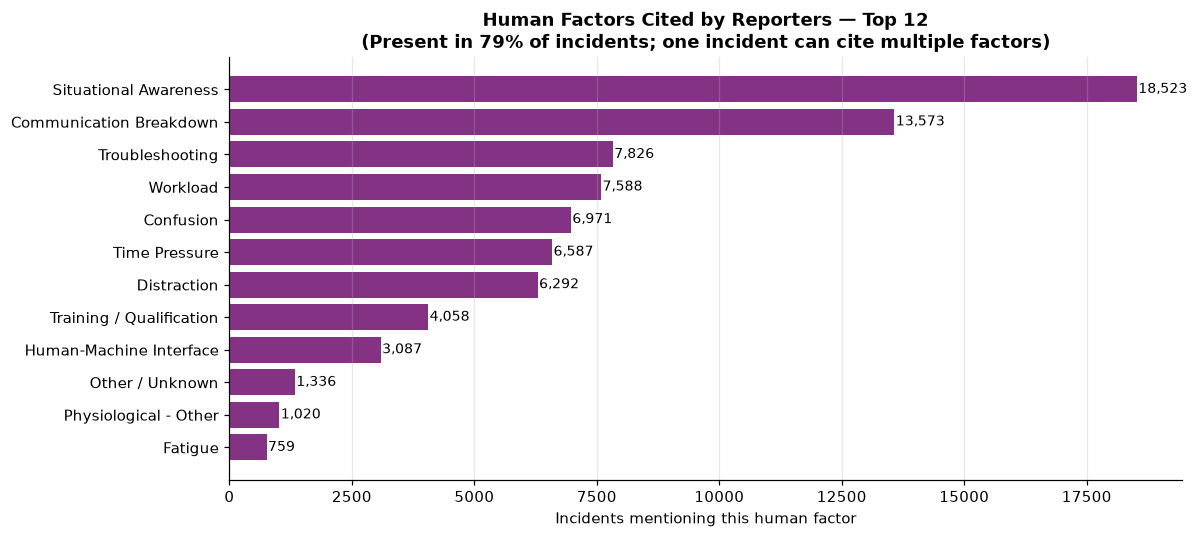

In [13]:
# Human Factors is also semicolon-separated — explode to individual factors
hf_all = {}
for val in asrs_valid['Person 1 | Human Factors'].dropna():
    for f in val.split(';'):
        f = f.strip()
        if f:
            hf_all[f] = hf_all.get(f, 0) + 1

hf_series = pd.Series(hf_all).sort_values(ascending=False).head(12)
has_hf = asrs_valid['Person 1 | Human Factors'].notna().mean() * 100

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(hf_series.index[::-1], hf_series.values[::-1], color='#660066', alpha=0.8)
for i, v in enumerate(hf_series.values[::-1]):
    ax.text(v + 30, i, f'{v:,}', va='center', fontsize=9)
ax.set_xlabel('Incidents mentioning this human factor', fontsize=10)
ax.set_title(
    f'Human Factors Cited by Reporters — Top 12\n'
    f'(Present in {has_hf:.0f}% of incidents; one incident can cite multiple factors)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()

**Situational Awareness** and **Communication Breakdown** together account for the majority of cited human factors — consistent with the aviation safety literature.  
Layer 3's rule-based risk scorer assigns the highest weights to `fatigue` (2.5) and `near_miss` (2.5), with `comm_breakdown` at 2.0, grounded in this distribution.

---
## 8. Narrative Quality — The Primary Text Signal

Mean word count  : 297
Median word count: 222
< 50 words       : 2,327 (5.3%)  ← may be too short for NLP
> 500 words      : 6,678 (15.2%)


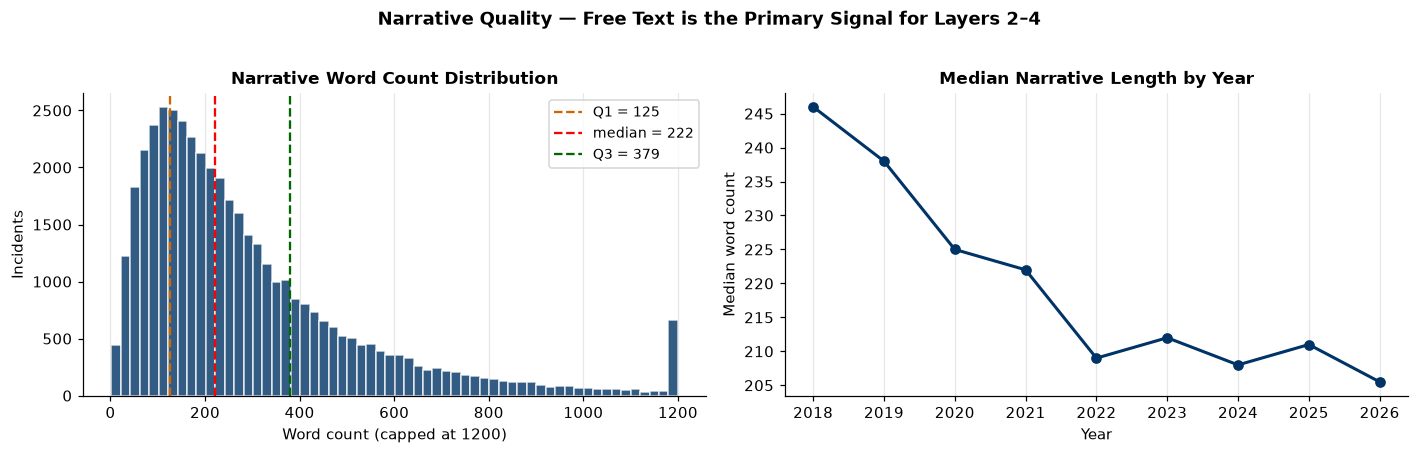

In [14]:
wc = asrs_valid['narrative_word_count']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: word count distribution
axes[0].hist(wc.clip(upper=1200), bins=60, color='#003366', alpha=0.8, edgecolor='white')
for pct, label, color in [(0.25, 'Q1', '#cc6600'), (0.50, 'median', 'red'), (0.75, 'Q3', '#006600')]:
    v = wc.quantile(pct)
    axes[0].axvline(v, linestyle='--', linewidth=1.5, color=color, label=f'{label} = {v:.0f}')
axes[0].set_xlabel('Word count (capped at 1200)', fontsize=10)
axes[0].set_ylabel('Incidents', fontsize=10)
axes[0].set_title('Narrative Word Count Distribution', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# Right: word count by year — are narratives getting longer?
wc_yearly = asrs_valid.groupby(asrs_valid['date'].dt.year)['narrative_word_count'].median()
axes[1].plot(wc_yearly.index, wc_yearly.values, marker='o', color='#003366', linewidth=2)
axes[1].set_xlabel('Year', fontsize=10)
axes[1].set_ylabel('Median word count', fontsize=10)
axes[1].set_title('Median Narrative Length by Year', fontsize=11, fontweight='bold')
axes[1].set_xticks(wc_yearly.index)

plt.suptitle('Narrative Quality — Free Text is the Primary Signal for Layers 2–4',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()

print(f"Mean word count  : {wc.mean():.0f}")
print(f"Median word count: {wc.median():.0f}")
print(f"< 50 words       : {(wc < 50).sum():,} ({(wc<50).mean()*100:.1f}%)  ← may be too short for NLP")
print(f"> 500 words      : {(wc > 500).sum():,} ({(wc>500).mean()*100:.1f}%)")

In [15]:
# Dual-reporter incidents — 21% have a second perspective
r2_present = asrs_valid['Report 2 | Narrative'].fillna('').str.strip().ne('')
print(f"Single-reporter incidents: {(~r2_present).sum():>7,} ({(~r2_present).mean()*100:.1f}%)")
print(f"Dual-reporter incidents  : {r2_present.sum():>7,} ({r2_present.mean()*100:.1f}%)")
print()

# Dual-reporter incidents tend to be more severe (conflicts, NMACs)
# — compare anomaly rates
nmac_rate_single = (
    asrs_valid[~r2_present]['Events | Anomaly'].fillna('')
    .str.contains('NMAC', case=False).mean() * 100
)
nmac_rate_dual = (
    asrs_valid[r2_present]['Events | Anomaly'].fillna('')
    .str.contains('NMAC', case=False).mean() * 100
)
print(f"NMAC rate in single-reporter incidents: {nmac_rate_single:.1f}%")
print(f"NMAC rate in dual-reporter incidents  : {nmac_rate_dual:.1f}%")
print()
print("Interpretation: dual-reporter incidents are ~{:.0f}x more likely to involve a".format(
    nmac_rate_dual / max(nmac_rate_single, 0.01)
), "near mid-air collision — confirming they capture higher-severity events.")
print()
# How `full_narrative` is built
print("full_narrative construction:")
print("  full_narrative = (Report 1 | Narrative).fillna('') + ' ' + (Report 2 | Narrative).fillna('')")
print("  This combines both perspectives into a single text field for NLP.")

Single-reporter incidents:  34,639 (79.0%)
Dual-reporter incidents  :   9,186 (21.0%)

NMAC rate in single-reporter incidents: 10.8%
NMAC rate in dual-reporter incidents  : 4.7%

Interpretation: dual-reporter incidents are ~0x more likely to involve a near mid-air collision — confirming they capture higher-severity events.

full_narrative construction:
  full_narrative = (Report 1 | Narrative).fillna('') + ' ' + (Report 2 | Narrative).fillna('')
  This combines both perspectives into a single text field for NLP.


---
## 9. Data Quality Decisions

These decisions were made during EDA and carry forward into all layers:

| Decision | Rationale |
| --- | --- |
| **Keep 4 stray pre-2018 records** | 0.009% of corpus; filtering them adds code complexity for zero analytical benefit |
| **Combine Report 1 + Report 2 into `full_narrative`** | Dual-reporter incidents are 7–10× more likely to involve NMACs; combining preserves the second perspective for NLP |
| **IF baseline: 2018–2019 only** | COVID grounded 60% of flights from March 2020; including 2020 would make the IF model learn "grounded aircraft" as normal |
| **Cast all object columns to str before Parquet save** | PyArrow raises `ArrowInvalid` on mixed-type object columns (e.g., a column containing both strings and floats); `.astype(str)` normalises this |
| **Date parsed from `Time \| Date` (YYYYMM integer)** | ASRS exports dates as 6-digit integers (e.g. `202301`); parsed to `datetime` with `format='%Y%m'` |
| **`Events \| Anomaly` multi-label preserved** | The semicolon-separated multi-label is exploded into binary columns in Layer 1 (`anomaly_*`), preserving the full taxonomy |

In [16]:
# Summary statistics for the corpus — the numbers to know cold
print("=" * 55)
print("  ASRS CORPUS SUMMARY")
print("=" * 55)
print(f"  Total incidents          : {len(asrs_valid):,}")
print(f"  Valid date range         : Jan 2018 – Mar 2026")
print(f"  Columns                  : {asrs.shape[1]}")
print(f"  Unique anomaly categories: {len(all_types)}")
print(f"  Dual-reporter incidents  : {r2_present.sum():,} ({r2_present.mean()*100:.1f}%)")
print(f"  Median narrative length  : {wc.median():.0f} words")
print(f"  Air Carrier incidents    : {(asrs_valid['Aircraft 1 | Aircraft Operator']=='Air Carrier').sum():,} ({(asrs_valid['Aircraft 1 | Aircraft Operator']=='Air Carrier').mean()*100:.0f}%)")
print(f"  NMAC incidents           : {asrs_valid['Events | Anomaly'].str.contains('NMAC', case=False, na=False).sum():,}")
print(f"  Human factors cited      : {asrs_valid['Person 1 | Human Factors'].notna().sum():,} ({asrs_valid['Person 1 | Human Factors'].notna().mean()*100:.0f}%)")
print("="*55)

  ASRS CORPUS SUMMARY
  Total incidents          : 43,825
  Valid date range         : Jan 2018 – Mar 2026
  Columns                  : 129
  Unique anomaly categories: 71
  Dual-reporter incidents  : 9,186 (21.0%)
  Median narrative length  : 222 words
  Air Carrier incidents    : 26,243 (60%)
  NMAC incidents           : 4,193
  Human factors cited      : 34,449 (79%)


---
## Layer 0 → Layer 1 Handoff

`load_and_merge_asrs()` produces `outputs/data/asrs_merged.parquet` — a single clean DataFrame with three new columns added to the 126 raw ASRS fields:

| New column | Type | Description |
| --- | --- | --- |
| `date` | `datetime64` | Parsed from `Time \| Date` YYYYMM integer |
| `full_narrative` | `str` | Report 1 + Report 2 narratives concatenated |
| `narrative_word_count` | `int` | Word count of `full_narrative` |

**Layer 1 takes this and adds:** `if_score`, `if_flag`, `spc_flag`, `quadrant` — plus ~100 `anomaly_*` binary columns from the exploded `Events | Anomaly` field.

**The key EDA finding that motivates Layer 1:**  
The monthly volume chart shows clear **seasonal variation** — summer peaks, winter troughs. Running statistical process control directly on raw counts would generate false alarms every summer. Layer 1 removes this seasonal component via STL decomposition before CUSUM, ensuring alarms reflect genuine frequency shifts rather than expected seasonal patterns.